# Beam tracking from many H5 files

This notebook processes one H5 file at a time. Each file is treated as one frame.

Expected H5 structure, based on your inspection:

```text
/data : 512 x 512 detector image
```

The notebook extracts only numerical tracking results and does not keep all images in memory.


## Fast version

This version fits the x and y projections of a cropped ROI. It is much faster than the full 2D fit.

In [50]:
# %% Imports
import re
from pathlib import Path

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.ndimage import gaussian_filter, center_of_mass
from scipy.optimize import least_squares

try:
    from tqdm import tqdm
except ImportError:
    tqdm = lambda x, **kwargs: x

In [51]:
# %% Folder and file list

# Put your three folders here, in acquisition order
data_folders = [
    Path(r"G:\UED_measurements\2026\07 July\02\r000293\RAW")
]

# Folder where results will be saved
output_folder = data_folders[0].parent / "beam_tracking_all_cuts"
output_folder.mkdir(exist_ok=True)

def file_sort_key(path):
    """
    Sort by numeric filename if possible.
    Example: 1782742652.079.h5 -> 1782742652.079
    Falls back to natural string sorting otherwise.
    """
    try:
        return (0, float(path.stem))
    except ValueError:
        return (1, [int(t) if t.isdigit() else t.lower()
                   for t in re.split(r"(\d+)", path.name)])

h5_files = []

for folder in data_folders:
    files_here = list(folder.glob("*.h5")) + list(folder.glob("*.hdf5"))
    files_here = sorted(files_here, key=file_sort_key)

    print(folder)
    print("  number of files:", len(files_here))
    if len(files_here) > 0:
        print("  first:", files_here[0].name)
        print("  last: ", files_here[-1].name)

    h5_files.extend(files_here)

# Global sorting across cut1, cut2, cut3
h5_files = sorted(h5_files, key=file_sort_key)

print("\nTotal number of H5 files:", len(h5_files))
print("First global file:", h5_files[0])
print("Last global file: ", h5_files[-1])

# Optional: check that the ordering is sensible
file_timestamps = []

for p in h5_files:
    try:
        file_timestamps.append(float(p.stem))
    except ValueError:
        file_timestamps.append(np.nan)

file_timestamps = np.asarray(file_timestamps, dtype=float)

if np.all(np.isfinite(file_timestamps)):
    dt = np.diff(file_timestamps)
    print("Median time step from filenames:", np.median(dt), "s")
    print("Minimum time step:", np.min(dt), "s")
    print("Maximum time step:", np.max(dt), "s")

    if np.any(dt <= 0):
        print("Warning: some files are not strictly increasing in timestamp.")

G:\UED_measurements\2026\07 July\02\r000293\RAW
  number of files: 50886
  first: 1783008011.445.h5
  last:  1783066191.981.h5

Total number of H5 files: 50886
First global file: G:\UED_measurements\2026\07 July\02\r000293\RAW\1783008011.445.h5
Last global file:  G:\UED_measurements\2026\07 July\02\r000293\RAW\1783066191.981.h5
Median time step from filenames: 1.1390001773834229 s
Minimum time step: 1.13100004196167 s
Maximum time step: 1.6400001049041748 s


In [52]:
# %% Inspect one H5 file

test_file = h5_files[0]
print("Testing:", test_file)

with h5py.File(test_file, "r") as f:
    def visitor(name, obj):
        if isinstance(obj, h5py.Dataset):
            print(f"{name}: shape={obj.shape}, dtype={obj.dtype}")
        else:
            print(f"{name}/")

    f.visititems(visitor)

    print("\nRoot attributes:")
    for k, v in f.attrs.items():
        print(k, "=", v)

    if "data" in f:
        print("\nDataset /data attributes:")
        for k, v in f["data"].attrs.items():
            print(k, "=", v)

Testing: G:\UED_measurements\2026\07 July\02\r000293\RAW\1783008011.445.h5
data: shape=(512, 512), dtype=int32

Root attributes:

Dataset /data attributes:
Acquisition_mode = INTS
Exposure_time_ms = 1000
Frame_time = 1000
LTS_position = 0.0
PHI_DEG = 0
PHI_RAW = 0
Pressure = 2.1266081566887065e-07
RF_Cavity_phase = 0.0
RF_Cavity_power = 0.0
Sensor_A_Ohm = 39.13
Sensor_B_Ohm = 36.75
Simstep_positions = [    0 26962 15450   650]
Temperature_A = 298.41
Temperature_B = 299.08
Time = 1783008011.447
Time_for_humans = 2026-07-02 18:00:11.448073
UV_power = 0.5
incident_energy = 40000
loop_number = 0
nimages = 1
notes = 
pump_area = 0.0
pump_power = 0.0
shutter = 0


In [53]:
# %% H5 reader

image_path = "data"

metadata_names = [
    "Pressure",
    "Temperature_A",
    "Temperature_B",
    "Time",
    "Time_for_humans",
    "Delay_ps",
    "RF_Cavity_phase",
    "RF_Cavity_power",
    "UV_power",
    "pump_power",
    "shutter",
]


def clean_h5_value(value):
    """Convert H5 scalars/bytes into convenient Python objects."""
    if isinstance(value, bytes):
        return value.decode(errors="ignore")

    if isinstance(value, np.ndarray):
        if value.shape == ():
            return clean_h5_value(value.item())
        if value.dtype.kind == "S":
            return value.astype(str)

    return value


def read_one_h5(path):
    """
    Read one H5 file.

    Returns
    -------
    image : 2D float32 array
    meta : dict
    """
    with h5py.File(path, "r") as f:
        image = f[image_path][()]

        meta = {}
        for name in metadata_names:
            if name in f.attrs:
                meta[name] = clean_h5_value(f.attrs[name])
            elif name in f[image_path].attrs:
                meta[name] = clean_h5_value(f[image_path].attrs[name])
            else:
                meta[name] = np.nan

    image = np.squeeze(image)

    if image.ndim != 2:
        raise ValueError(f"Expected 2D image, got shape {image.shape}")

    # Filenames look like timestamps, e.g. 1782742652.079.h5
    try:
        meta["file_timestamp"] = float(Path(path).stem)
    except ValueError:
        meta["file_timestamp"] = np.nan

    return image.astype(np.float32, copy=False), meta

Image shape: (512, 512)
Image min/max: 0.0 19003.0
{'Pressure': 2.1266081566887065e-07, 'Temperature_A': 298.41, 'Temperature_B': 299.08, 'Time': '1783008011.447', 'Time_for_humans': '2026-07-02 18:00:11.448073', 'Delay_ps': nan, 'RF_Cavity_phase': 0.0, 'RF_Cavity_power': 0.0, 'UV_power': 0.5, 'pump_power': 0.0, 'shutter': 0, 'file_timestamp': 1783008011.445}


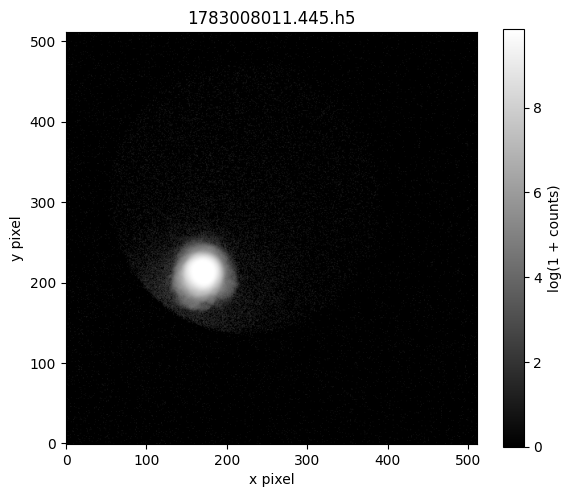

In [54]:
# %% Test reader and display first image

image, meta = read_one_h5(h5_files[0])

print("Image shape:", image.shape)
print("Image min/max:", np.nanmin(image), np.nanmax(image))
print(meta)

plt.figure(figsize=(6, 5))
plt.imshow(np.log1p(image), origin="lower", cmap="gray")
plt.colorbar(label="log(1 + counts)")
plt.xlabel("x pixel")
plt.ylabel("y pixel")
plt.title(h5_files[0].name)
plt.tight_layout()
plt.show()

In [55]:
# %% Plot helpers

def robust_ylim(y, q_low=0.5, q_high=99.5, margin_frac=0.10):
    y = np.asarray(y, dtype=float)
    y = y[np.isfinite(y)]

    if y.size == 0:
        return 0, 1

    ymin, ymax = np.percentile(y, [q_low, q_high])

    if not np.isfinite(ymin) or not np.isfinite(ymax):
        return 0, 1

    if ymax == ymin:
        margin = 1.0 if ymax == 0 else 0.1 * abs(ymax)
    else:
        margin = margin_frac * (ymax - ymin)

    return ymin - margin, ymax + margin


def robust_ylim_multi(arrays, q_low=0.5, q_high=99.5, margin_frac=0.10):
    values = []
    for arr in arrays:
        arr = np.asarray(arr, dtype=float)
        arr = arr[np.isfinite(arr)]
        if arr.size > 0:
            values.append(arr)

    if not values:
        return 0, 1

    y = np.concatenate(values)
    return robust_ylim(y, q_low=q_low, q_high=q_high, margin_frac=margin_frac)


def find_existing_column(candidates, df):
    for col in candidates:
        if col in df.columns:
            return col
    raise KeyError(f"None of these columns found: {candidates}")

In [56]:
# %% Tracking and fitting parameters

# Change this after looking at the model comparison table.
chosen_model = "gaussian"     # "gaussian" or "pvoigt"

# ROI used for the moving fit around the beam.
fit_roi_half_size = 80

# Used only for finding the initial center and robust guesses.
smooth_sigma = 1.0
background_percentile = 10
threshold_rel = 0.10

# Counts inside fitted ellipse: 1.0 means inside the FWHM ellipse.
fit_count_scale = 1.0

# Fixed ROI based on the first frame.
# Use a generous ROI so the beam stays inside even if it drifts.
fixed_roi_scale = 3.0
fixed_extra_pix_x = 20
fixed_extra_pix_y = 20

scatter_size = 3
scatter_alpha = 0.7

In [57]:
# %% 1D profile models, used by the fast method and by fixed-ROI FWHM

LN2 = np.log(2)


def gaussian_1d(p, x):
    offset, amp, x0, fwhm = p
    u = (x - x0) / (fwhm / 2)
    return offset + amp * np.exp(-LN2 * u**2)


def pvoigt_1d(p, x):
    offset, amp, x0, fwhm, eta = p
    u = (x - x0) / (fwhm / 2)

    gaussian_part = np.exp(-LN2 * u**2)
    lorentzian_part = 1 / (1 + u**2)

    return offset + amp * ((1 - eta) * gaussian_part + eta * lorentzian_part)


def fit_profile_1d(profile, model_name="gaussian"):
    profile = np.asarray(profile, dtype=np.float32)
    x = np.arange(profile.size, dtype=np.float32)

    offset0 = np.percentile(profile, 10)
    amp0 = np.max(profile) - offset0
    x0_0 = np.argmax(profile)

    halfmax = offset0 + amp0 / 2
    above = np.where(profile > halfmax)[0]

    if len(above) > 2:
        fwhm0 = above[-1] - above[0]
    else:
        fwhm0 = profile.size / 4

    fwhm0 = max(3, fwhm0)

    if model_name == "gaussian":
        p0 = [offset0, amp0, x0_0, fwhm0]
        lower = [-np.inf, 0, 0, 2]
        upper = [np.inf, np.inf, profile.size - 1, profile.size]
        model_fun = gaussian_1d

    elif model_name == "pvoigt":
        p0 = [offset0, amp0, x0_0, fwhm0, 0.5]
        lower = [-np.inf, 0, 0, 2, 0]
        upper = [np.inf, np.inf, profile.size - 1, profile.size, 1]
        model_fun = pvoigt_1d

    else:
        raise ValueError("model_name must be 'gaussian' or 'pvoigt'")

    def residuals(p):
        return model_fun(p, x) - profile

    result = least_squares(
        residuals,
        p0,
        bounds=(lower, upper),
        loss="soft_l1",
        max_nfev=300,
        x_scale="jac",
    )

    p = result.x
    fit = model_fun(p, x)
    rss = np.sum((profile - fit)**2)
    rmse = np.sqrt(rss / profile.size)

    return {
        "success": result.success,
        "offset": p[0],
        "amplitude": p[1],
        "center": p[2],
        "fwhm": p[3],
        "eta": p[4] if model_name == "pvoigt" else np.nan,
        "rmse": rmse,
        "fit": fit,
    }

In [58]:
# %% Fast beam fit using 1D projections of a cropped ROI

def fit_beam_image_fast(
    image,
    model_name="gaussian",
    previous_center=None,
    roi_half_size=80,
    smooth_sigma=1.0,
):
    image = np.asarray(image, dtype=np.float32)
    image = np.nan_to_num(image, nan=0.0, posinf=0.0, neginf=0.0)

    ny, nx = image.shape

    if previous_center is None:
        smoothed = gaussian_filter(image, smooth_sigma)
        y_guess, x_guess = np.unravel_index(np.argmax(smoothed), smoothed.shape)
    else:
        x_guess, y_guess = previous_center

    x0 = max(0, int(round(x_guess)) - roi_half_size)
    x1 = min(nx, int(round(x_guess)) + roi_half_size + 1)

    y0 = max(0, int(round(y_guess)) - roi_half_size)
    y1 = min(ny, int(round(y_guess)) + roi_half_size + 1)

    crop = image[y0:y1, x0:x1]

    profile_x = np.sum(crop, axis=0)
    profile_y = np.sum(crop, axis=1)

    fit_x = fit_profile_1d(profile_x, model_name=model_name)
    fit_y = fit_profile_1d(profile_y, model_name=model_name)

    x_center = x0 + fit_x["center"]
    y_center = y0 + fit_y["center"]

    rmse = np.nanmean([fit_x["rmse"], fit_y["rmse"]])

    return {
        "model": model_name,
        "success": fit_x["success"] and fit_y["success"],

        "x_pix": x_center,
        "y_pix": y_center,

        "fwhm_x_pix": fit_x["fwhm"],
        "fwhm_y_pix": fit_y["fwhm"],

        "eta_x": fit_x["eta"],
        "eta_y": fit_y["eta"],

        "amplitude_x": fit_x["amplitude"],
        "amplitude_y": fit_y["amplitude"],

        "offset_x": fit_x["offset"],
        "offset_y": fit_y["offset"],

        "rmse_x": fit_x["rmse"],
        "rmse_y": fit_y["rmse"],
        "rmse": rmse,

        "crop": crop,
        "profile_x": profile_x,
        "profile_y": profile_y,
        "fit_x": fit_x["fit"],
        "fit_y": fit_y["fit"],
        "crop_bounds": (x0, x1, y0, y1),
    }

In [59]:
# %% Counts and fixed-ROI FWHM helpers

def counts_in_fixed_roi(image, fixed_center_x, fixed_center_y, fixed_half_x, fixed_half_y):
    ny, nx = image.shape

    x0 = max(0, int(round(fixed_center_x)) - fixed_half_x)
    x1 = min(nx, int(round(fixed_center_x)) + fixed_half_x + 1)

    y0 = max(0, int(round(fixed_center_y)) - fixed_half_y)
    y1 = min(ny, int(round(fixed_center_y)) + fixed_half_y + 1)

    roi = image[y0:y1, x0:x1]

    raw_counts = np.sum(roi)

    bg = np.percentile(roi, background_percentile)
    bgsub_counts = np.sum(np.clip(roi - bg, 0, None))

    return raw_counts, bgsub_counts, roi.size, (x0, x1, y0, y1)


def fwhm_from_fixed_roi_profiles(
    image,
    fixed_center_x,
    fixed_center_y,
    fixed_half_x,
    fixed_half_y,
    model_name="gaussian",
):
    """
    Compute FWHM x/y from the same fixed rectangular ROI for every frame.

    The ROI does not move or resize after it is defined from the first frame.
    The fitted width inside the ROI is still allowed to change.
    """
    ny, nx = image.shape

    x0 = max(0, int(round(fixed_center_x)) - fixed_half_x)
    x1 = min(nx, int(round(fixed_center_x)) + fixed_half_x + 1)

    y0 = max(0, int(round(fixed_center_y)) - fixed_half_y)
    y1 = min(ny, int(round(fixed_center_y)) + fixed_half_y + 1)

    roi = image[y0:y1, x0:x1]

    profile_x = np.sum(roi, axis=0)
    profile_y = np.sum(roi, axis=1)

    fit_x = fit_profile_1d(profile_x, model_name=model_name)
    fit_y = fit_profile_1d(profile_y, model_name=model_name)

    fixed_x_pix = x0 + fit_x["center"]
    fixed_y_pix = y0 + fit_y["center"]

    return {
        "fixed_x_pix": fixed_x_pix,
        "fixed_y_pix": fixed_y_pix,
        "fixed_fwhm_x_pix": fit_x["fwhm"],
        "fixed_fwhm_y_pix": fit_y["fwhm"],
        "fixed_eta_x": fit_x["eta"],
        "fixed_eta_y": fit_y["eta"],
        "fixed_rmse_x": fit_x["rmse"],
        "fixed_rmse_y": fit_y["rmse"],
        "fixed_roi_bounds": (x0, x1, y0, y1),
    }

In [60]:
# %% Fast fit-defined ellipse counts

def counts_in_fit_roi_fast(image, fit, scale=1.0):
    x0, x1, y0, y1 = fit["crop_bounds"]
    crop = image[y0:y1, x0:x1]

    yy, xx = np.indices(crop.shape)

    cx = fit["x_pix"] - x0
    cy = fit["y_pix"] - y0

    rx = max(scale * fit["fwhm_x_pix"] / 2, 1)
    ry = max(scale * fit["fwhm_y_pix"] / 2, 1)

    mask = ((xx - cx) / rx)**2 + ((yy - cy) / ry)**2 <= 1

    raw_counts = np.sum(crop[mask])

    bg = np.percentile(crop, background_percentile)
    bgsub_counts = np.sum(np.clip(crop[mask] - bg, 0, None))

    return raw_counts, bgsub_counts, np.sum(mask)

In [61]:
# %% Compare Gaussian and pseudo-Voigt on selected files

selected_indices = sorted(set([0, len(h5_files) // 2, len(h5_files) - 1]))

comparison_rows = []
fit_checks = {}

for idx in selected_indices:
    path = h5_files[idx]
    image, meta = read_one_h5(path)

    for model_name in ["gaussian", "pvoigt"]:
        fit = fit_beam_image_fast(
            image,
            model_name=model_name,
            previous_center=None,
            roi_half_size=fit_roi_half_size,
            smooth_sigma=smooth_sigma,
        )

        comparison_rows.append({
            "file_index": idx,
            "filename": path.name,
            "model": model_name,
            "success": fit["success"],
            "x_pix": fit["x_pix"],
            "y_pix": fit["y_pix"],
            "fwhm_x_pix": fit["fwhm_x_pix"],
            "fwhm_y_pix": fit["fwhm_y_pix"],
            "eta_x": fit["eta_x"],
            "eta_y": fit["eta_y"],
            "rmse_x": fit["rmse_x"],
            "rmse_y": fit["rmse_y"],
            "rmse": fit["rmse"],
        })

        fit_checks[(idx, model_name)] = fit

comparison = pd.DataFrame(comparison_rows)
display(comparison)

display(comparison.groupby("model")[["rmse_x", "rmse_y", "rmse"]].median())

chosen_model = comparison.groupby("model")["rmse"].median().idxmin()
print("Chosen model based on median RMSE:", chosen_model)

# Override manually if needed:
# chosen_model = "gaussian"
# chosen_model = "pvoigt"

,file_index,filename,model,success,x_pix,y_pix,fwhm_x_pix,fwhm_y_pix,eta_x,eta_y,rmse_x,rmse_y,rmse
0,0,1783008011.445.h5,gaussian,True,169.285419,212.657813,27.044114,27.662265,NaN,NaN,32617.051389,34930.813975,33773.932682
1,0,1783008011.445.h5,pvoigt,True,169.077133,212.592198,26.807882,27.651106,0.270646,0.188248,41641.564252,40521.564049,41081.564151
2,25443,1783037193.352.h5,gaussian,True,169.543235,214.101943,27.566967,28.413414,NaN,NaN,39958.651961,40410.280077,40184.466019
3,25443,1783037193.352.h5,pvoigt,True,169.533866,214.104209,27.548562,28.884444,0.001365,0.177410,40045.612275,45499.356771,42772.484523
4,50885,1783066191.981.h5,gaussian,True,169.538473,213.942353,27.568626,27.950967,NaN,NaN,38556.770175,40586.177378,39571.473777
5,50885,1783066191.981.h5,pvoigt,True,169.509731,213.850788,28.445511,28.120479,0.183285,0.237683,43786.696743,47185.487172,45486.091957


,rmse_x,rmse_y,rmse
model,,,
gaussian,38556.770175,40410.280077,39571.473777
pvoigt,41641.564252,45499.356771,42772.484523


Chosen model based on median RMSE: gaussian


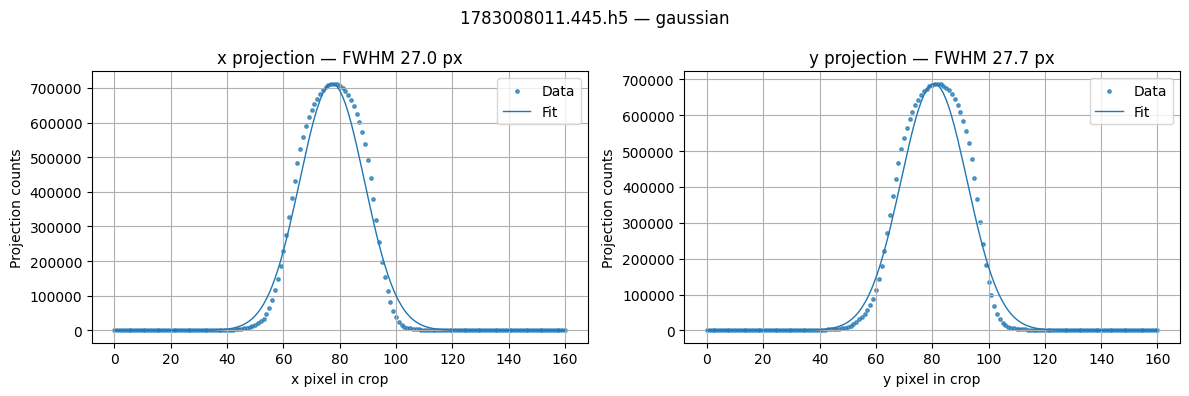

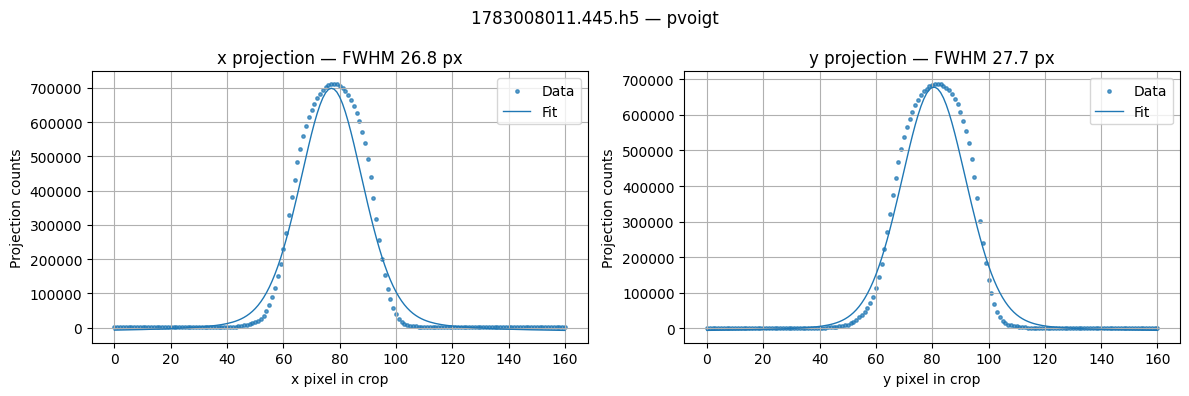

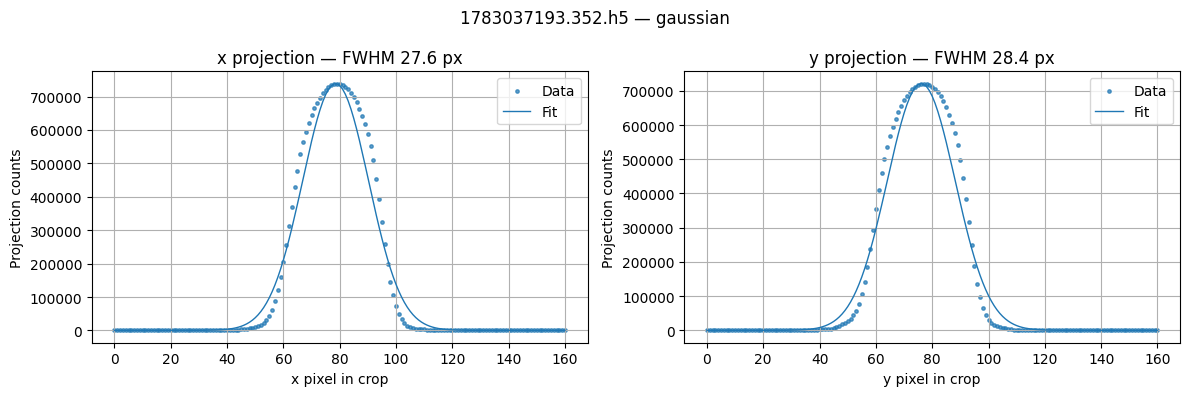

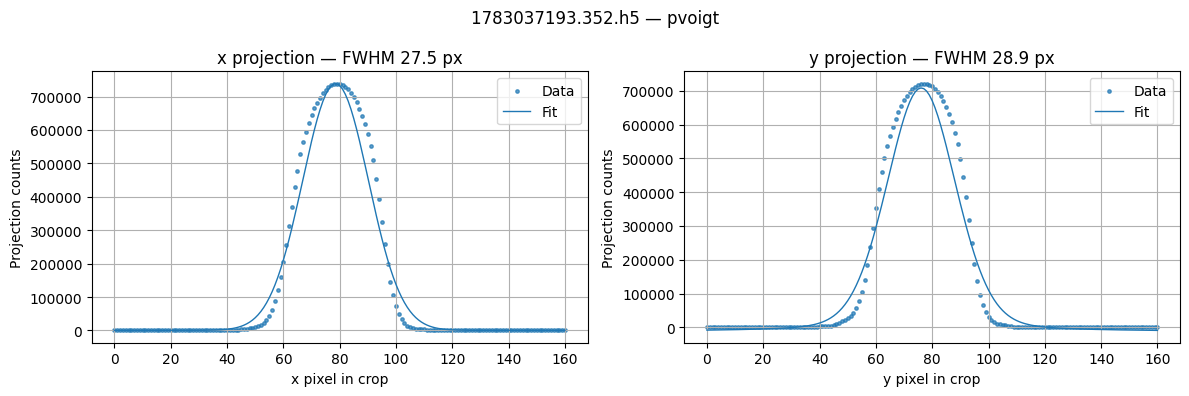

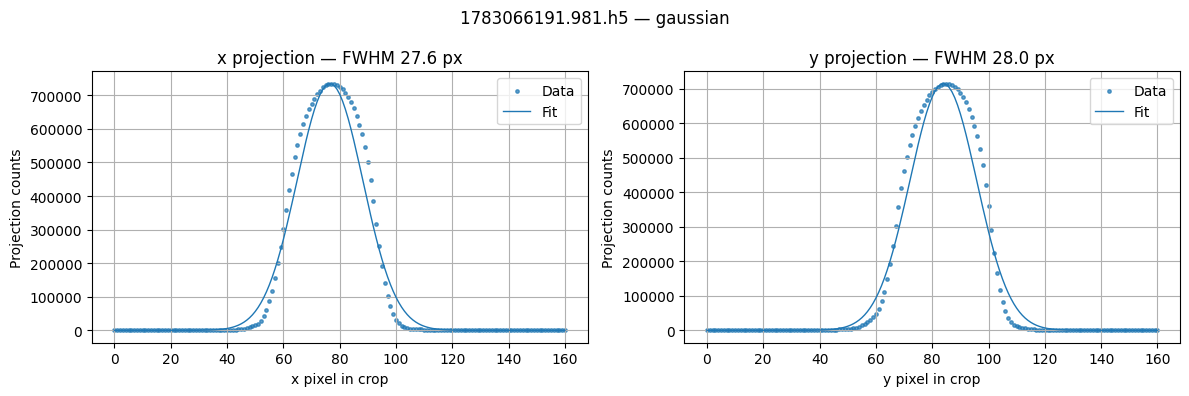

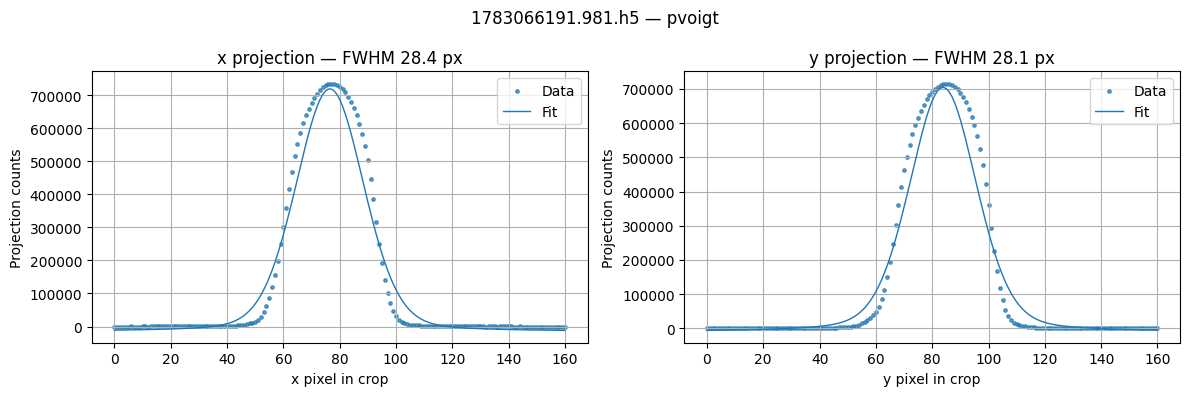

In [62]:
# %% Plot selected projection fits

for idx in selected_indices:
    for model_name in ["gaussian", "pvoigt"]:
        fit = fit_checks[(idx, model_name)]

        fig, axes = plt.subplots(1, 2, figsize=(12, 4))

        x = np.arange(len(fit["profile_x"]))
        y = np.arange(len(fit["profile_y"]))

        axes[0].scatter(x, fit["profile_x"], s=6, alpha=0.7, label="Data")
        axes[0].plot(x, fit["fit_x"], linewidth=1.0, label="Fit")
        axes[0].set_xlabel("x pixel in crop")
        axes[0].set_ylabel("Projection counts")
        axes[0].set_title(f"x projection — FWHM {fit['fwhm_x_pix']:.1f} px")
        axes[0].legend()
        axes[0].grid(True)

        axes[1].scatter(y, fit["profile_y"], s=6, alpha=0.7, label="Data")
        axes[1].plot(y, fit["fit_y"], linewidth=1.0, label="Fit")
        axes[1].set_xlabel("y pixel in crop")
        axes[1].set_ylabel("Projection counts")
        axes[1].set_title(f"y projection — FWHM {fit['fwhm_y_pix']:.1f} px")
        axes[1].legend()
        axes[1].grid(True)

        fig.suptitle(f"{h5_files[idx].name} — {model_name}")
        plt.tight_layout()
        plt.show()

In [63]:
# %% Define fixed ROI from first frame

first_image, first_meta = read_one_h5(h5_files[0])

first_fit = fit_beam_image_fast(
    first_image,
    model_name=chosen_model,
    previous_center=None,
    roi_half_size=fit_roi_half_size,
    smooth_sigma=smooth_sigma,
)

fixed_center_x = first_fit["x_pix"]
fixed_center_y = first_fit["y_pix"]

fixed_half_x = int(np.ceil(fixed_roi_scale * first_fit["fwhm_x_pix"] / 2 + fixed_extra_pix_x))
fixed_half_y = int(np.ceil(fixed_roi_scale * first_fit["fwhm_y_pix"] / 2 + fixed_extra_pix_y))

print("Fixed ROI center:", fixed_center_x, fixed_center_y)
print("Fixed ROI half-size x/y:", fixed_half_x, fixed_half_y)

Fixed ROI center: 169.28541895500575 212.65781256278783
Fixed ROI half-size x/y: 61 62


In [64]:
# %% Main loop — fast 1D projection fit on every file

results_rows = []
previous_center = None

for frame_index, path in enumerate(tqdm(h5_files)):
    image, meta = read_one_h5(path)

    fit = fit_beam_image_fast(
        image,
        model_name=chosen_model,
        previous_center=previous_center,
        roi_half_size=fit_roi_half_size,
        smooth_sigma=smooth_sigma,
    )

    if fit["success"] and np.isfinite(fit["x_pix"]) and np.isfinite(fit["y_pix"]):
        previous_center = (fit["x_pix"], fit["y_pix"])

    fit_counts_raw, fit_counts_bgsub, fit_area_pixels = counts_in_fit_roi_fast(
        image,
        fit,
        scale=fit_count_scale,
    )

    fixed_counts_raw, fixed_counts_bgsub, fixed_area_pixels, fixed_roi_bounds = counts_in_fixed_roi(
        image,
        fixed_center_x,
        fixed_center_y,
        fixed_half_x,
        fixed_half_y,
    )

    fixed_width = fwhm_from_fixed_roi_profiles(
        image,
        fixed_center_x,
        fixed_center_y,
        fixed_half_x,
        fixed_half_y,
        model_name=chosen_model,
    )

    row = {
        "frame": frame_index,
        "filename": path.name,
        "file_timestamp": meta.get("file_timestamp", np.nan),
        "model": chosen_model,
        "success": fit["success"],

        "x_pix": fit["x_pix"],
        "y_pix": fit["y_pix"],
        "fwhm_x_pix": fit["fwhm_x_pix"],
        "fwhm_y_pix": fit["fwhm_y_pix"],
        "eta_x": fit["eta_x"],
        "eta_y": fit["eta_y"],

        "fixed_x_pix": fixed_width["fixed_x_pix"],
        "fixed_y_pix": fixed_width["fixed_y_pix"],
        "fixed_fwhm_x_pix": fixed_width["fixed_fwhm_x_pix"],
        "fixed_fwhm_y_pix": fixed_width["fixed_fwhm_y_pix"],
        "fixed_eta_x": fixed_width["fixed_eta_x"],
        "fixed_eta_y": fixed_width["fixed_eta_y"],
        "fixed_rmse_x": fixed_width["fixed_rmse_x"],
        "fixed_rmse_y": fixed_width["fixed_rmse_y"],

        "amplitude_x": fit["amplitude_x"],
        "amplitude_y": fit["amplitude_y"],
        "offset_x": fit["offset_x"],
        "offset_y": fit["offset_y"],
        "rmse_x": fit["rmse_x"],
        "rmse_y": fit["rmse_y"],
        "rmse": fit["rmse"],

        "fit_counts_raw": fit_counts_raw,
        "fit_counts_bgsub": fit_counts_bgsub,
        "fit_area_pixels": fit_area_pixels,

        "fixed_counts_raw": fixed_counts_raw,
        "fixed_counts_bgsub": fixed_counts_bgsub,
        "fixed_area_pixels": fixed_area_pixels,
    }

    row.update(meta)
    results_rows.append(row)

tracking = pd.DataFrame(results_rows)

tracking["dx_pix"] = tracking["x_pix"] - tracking["x_pix"].iloc[0]
tracking["dy_pix"] = tracking["y_pix"] - tracking["y_pix"].iloc[0]
tracking["fixed_dx_pix"] = tracking["fixed_x_pix"] - tracking["fixed_x_pix"].iloc[0]
tracking["fixed_dy_pix"] = tracking["fixed_y_pix"] - tracking["fixed_y_pix"].iloc[0]
tracking["time_s"] = tracking["file_timestamp"] - tracking["file_timestamp"].iloc[0]

tracking.head()

100%|██████████| 50886/50886 [37:45<00:00, 22.46it/s]


,frame,filename,file_timestamp,model,success,x_pix,y_pix,fwhm_x_pix,fwhm_y_pix,eta_x,...,RF_Cavity_phase,RF_Cavity_power,UV_power,pump_power,shutter,dx_pix,dy_pix,fixed_dx_pix,fixed_dy_pix,time_s
0,0,1783008011.445.h5,1.783008e+09,gaussian,True,169.285419,212.657813,27.044114,27.662265,NaN,...,0.0,0.0,0.5,0.0,0,0.000000,0.000000,0.000000,0.000000,0.000
1,1,1783008012.585.h5,1.783008e+09,gaussian,True,169.142545,212.814223,26.804959,27.916263,NaN,...,0.0,0.0,0.5,0.0,0,-0.142874,0.156410,0.165168,0.107188,1.140
2,2,1783008013.736.h5,1.783008e+09,gaussian,True,169.074019,212.633935,26.799346,27.629344,NaN,...,0.0,0.0,0.5,0.0,0,-0.211400,-0.023878,0.110958,-0.008940,2.291
3,3,1783008014.878.h5,1.783008e+09,gaussian,True,169.097771,212.768469,26.803931,27.663135,NaN,...,0.0,0.0,0.5,0.0,0,-0.187648,0.110657,-0.018785,0.074753,3.433
4,4,1783008016.017.h5,1.783008e+09,gaussian,True,169.032474,212.754414,26.844901,27.524937,NaN,...,0.0,0.0,0.5,0.0,0,-0.252945,0.096602,-0.035557,0.106074,4.572


In [65]:
# %% Save results

output_csv = output_folder / "beam_tracking_results_fast_1d.csv"
output_pkl = output_folder / "beam_tracking_results_fast_1d.pkl"

tracking.to_csv(output_csv, index=False)
tracking.to_pickle(output_pkl)

print("Saved:", output_csv)
print("Saved:", output_pkl)

Saved: G:\UED_measurements\2026\07 July\02\r000293\beam_tracking_all_cuts\beam_tracking_results_fast_1d.csv
Saved: G:\UED_measurements\2026\07 July\02\r000293\beam_tracking_all_cuts\beam_tracking_results_fast_1d.pkl


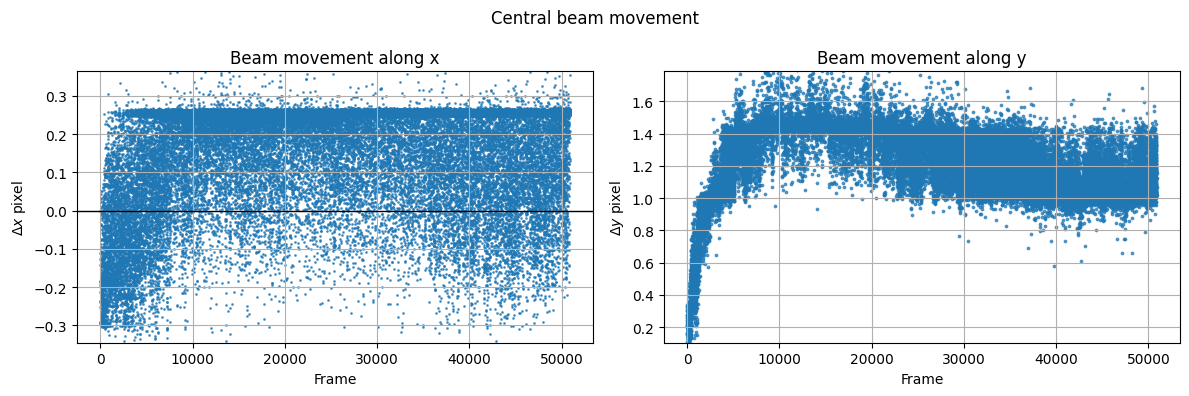

In [66]:
# %% Plot beam movement

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

axes[0].scatter(tracking["frame"], tracking["dx_pix"], s=1, alpha=scatter_alpha)
axes[0].axhline(0, color="k", lw=1)
axes[0].set_xlabel("Frame")
axes[0].set_ylabel(r"$\Delta x$ pixel")
axes[0].set_title("Beam movement along x")
axes[0].set_ylim(robust_ylim(tracking["dx_pix"]))
axes[0].grid(True)

axes[1].scatter(tracking["frame"], tracking["dy_pix"], s=scatter_size, alpha=scatter_alpha)
axes[1].axhline(0, color="k", lw=1)
axes[1].set_xlabel("Frame")
axes[1].set_ylabel(r"$\Delta y$ pixel")
axes[1].set_title("Beam movement along y")
axes[1].set_ylim(robust_ylim(tracking["dy_pix"]))
axes[1].grid(True)

fig.suptitle("Central beam movement")
plt.tight_layout()
plt.show()

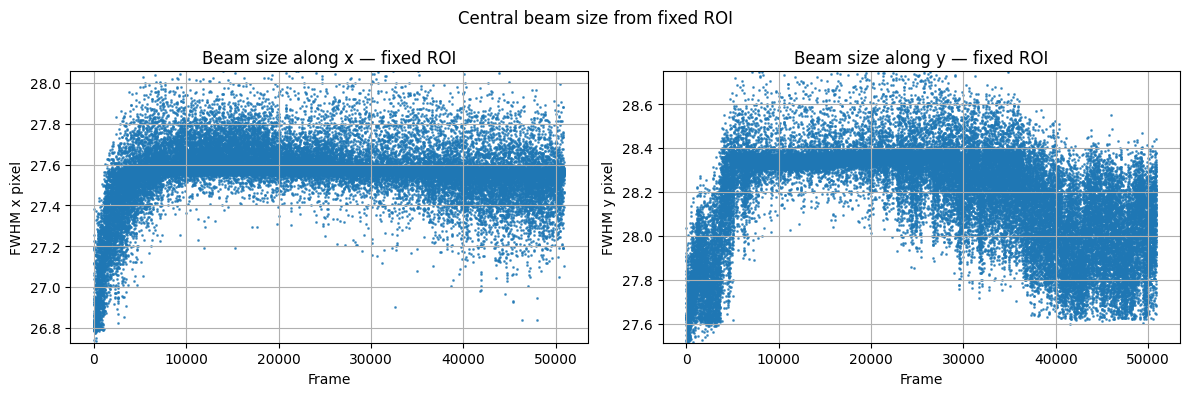

In [67]:
# %% Plot beam size from fixed ROI only

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

axes[0].scatter(tracking["frame"], tracking["fixed_fwhm_x_pix"], s=1, alpha=scatter_alpha)
axes[0].set_xlabel("Frame")
axes[0].set_ylabel("FWHM x pixel")
axes[0].set_title("Beam size along x — fixed ROI")
axes[0].set_ylim(robust_ylim(tracking["fixed_fwhm_x_pix"]))
axes[0].grid(True)

axes[1].scatter(tracking["frame"], tracking["fixed_fwhm_y_pix"], s=1, alpha=scatter_alpha)
axes[1].set_xlabel("Frame")
axes[1].set_ylabel("FWHM y pixel")
axes[1].set_title("Beam size along y — fixed ROI")
axes[1].set_ylim(robust_ylim(tracking["fixed_fwhm_y_pix"]))
axes[1].grid(True)

fig.suptitle("Central beam size from fixed ROI")
plt.tight_layout()
plt.show()

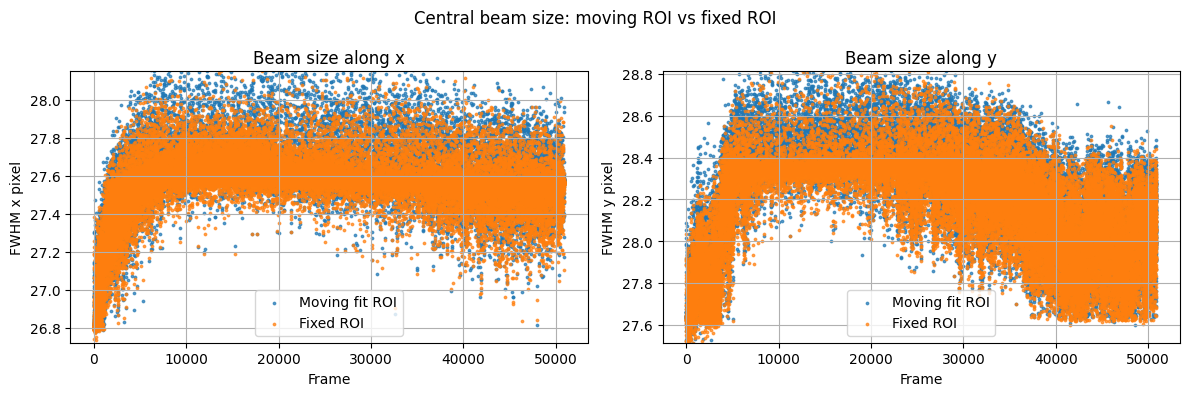

In [68]:
# %% Compare moving fit ROI FWHM and fixed ROI FWHM

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

axes[0].scatter(
    tracking["frame"],
    tracking["fwhm_x_pix"],
    s=scatter_size,
    alpha=scatter_alpha,
    label="Moving fit ROI",
)
axes[0].scatter(
    tracking["frame"],
    tracking["fixed_fwhm_x_pix"],
    s=scatter_size,
    alpha=scatter_alpha,
    label="Fixed ROI",
)
axes[0].set_xlabel("Frame")
axes[0].set_ylabel("FWHM x pixel")
axes[0].set_title("Beam size along x")
axes[0].set_ylim(robust_ylim_multi([tracking["fwhm_x_pix"], tracking["fixed_fwhm_x_pix"]]))
axes[0].grid(True)
axes[0].legend()

axes[1].scatter(
    tracking["frame"],
    tracking["fwhm_y_pix"],
    s=scatter_size,
    alpha=scatter_alpha,
    label="Moving fit ROI",
)
axes[1].scatter(
    tracking["frame"],
    tracking["fixed_fwhm_y_pix"],
    s=scatter_size,
    alpha=scatter_alpha,
    label="Fixed ROI",
)
axes[1].set_xlabel("Frame")
axes[1].set_ylabel("FWHM y pixel")
axes[1].set_title("Beam size along y")
axes[1].set_ylim(robust_ylim_multi([tracking["fwhm_y_pix"], tracking["fixed_fwhm_y_pix"]]))
axes[1].grid(True)
axes[1].legend()

fig.suptitle("Central beam size: moving ROI vs fixed ROI")
plt.tight_layout()
plt.show()

Using fit-count column: fit_counts_bgsub
Using fixed-ROI column: fixed_counts_bgsub


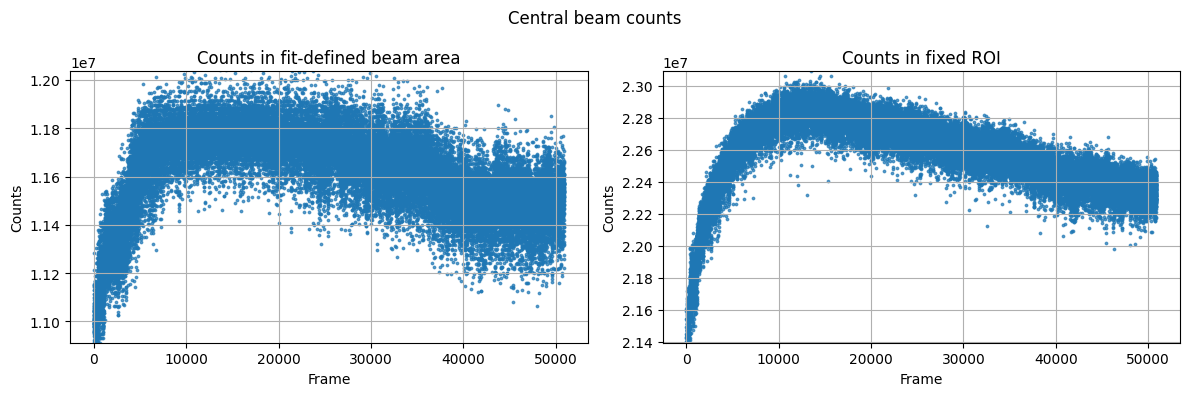

In [69]:
# %% Plot counts

fit_count_col = find_existing_column(["fit_counts_bgsub", "fit_counts_raw"], tracking)
fixed_count_col = find_existing_column(["fixed_counts_bgsub", "fixed_counts_raw"], tracking)

print("Using fit-count column:", fit_count_col)
print("Using fixed-ROI column:", fixed_count_col)

y_fit = pd.to_numeric(tracking[fit_count_col], errors="coerce")
y_fixed = pd.to_numeric(tracking[fixed_count_col], errors="coerce")

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

axes[0].scatter(tracking["frame"], y_fit, s=scatter_size, alpha=scatter_alpha)
axes[0].set_xlabel("Frame")
axes[0].set_ylabel("Counts")
axes[0].set_title("Counts in fit-defined beam area")
axes[0].set_ylim(robust_ylim(y_fit))
axes[0].grid(True)

axes[1].scatter(tracking["frame"], y_fixed, s=scatter_size, alpha=scatter_alpha)
axes[1].set_xlabel("Frame")
axes[1].set_ylabel("Counts")
axes[1].set_title("Counts in fixed ROI")
axes[1].set_ylim(robust_ylim(y_fixed))
axes[1].grid(True)

fig.suptitle("Central beam counts")
plt.tight_layout()
plt.show()

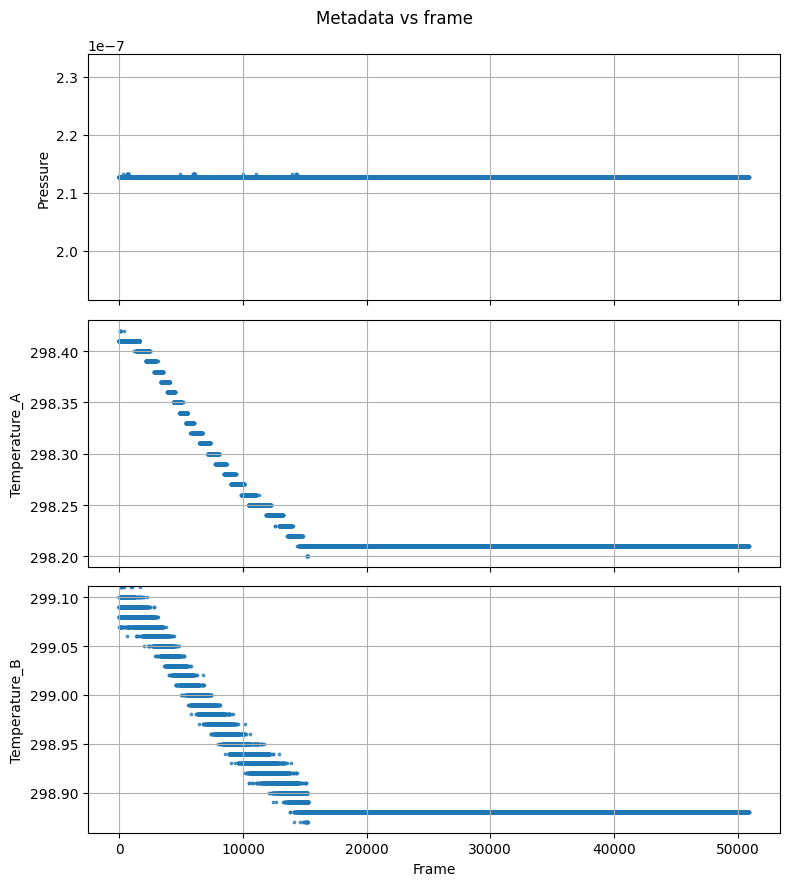

In [70]:
# %% Plot pressure and temperatures if they are available

available_meta = []
for col in ["Pressure", "Temperature_A", "Temperature_B"]:
    if col in tracking.columns:
        y = pd.to_numeric(tracking[col], errors="coerce")
        if np.isfinite(y).any():
            available_meta.append(col)

if not available_meta:
    print("No pressure/temperature metadata found in these H5 files.")
else:
    fig, axes = plt.subplots(len(available_meta), 1, figsize=(8, 3 * len(available_meta)), sharex=True)

    if len(available_meta) == 1:
        axes = [axes]

    for ax, col in zip(axes, available_meta):
        y = pd.to_numeric(tracking[col], errors="coerce")
        ax.scatter(tracking["frame"], y, s=scatter_size, alpha=scatter_alpha)
        ax.set_ylabel(col)
        ax.set_ylim(robust_ylim(y))
        ax.grid(True)

    axes[-1].set_xlabel("Frame")
    fig.suptitle("Metadata vs frame")
    plt.tight_layout()
    plt.show()